In [ ]:
import requests

CLIENT_ID = "1000.ZR1LQT5PK4B2RPU0YL6H2KE5A4RZDU"
CLIENT_SECRET = "ecce01ec8b3a21fc991a9e2f4c9d425a6e42957174"
REFRESH_TOKEN = "1000.6adb77f6f7493307d29a07e1cded7cfb.bb226b75b1713a764f7669af29efab17"

def generate_access_token():
    url = "https://accounts.zoho.com/oauth/v2/token"
    data = {
        "refresh_token": REFRESH_TOKEN,
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "grant_type": "refresh_token"
    }
    response = requests.post(url, data=data)
    result = response.json()
    if "access_token" in result:
        print("✅ Access token generated successfully!")
        return result["access_token"]
    else:
        print("❌ Error generating access token:", result)
        return None

access_token = generate_access_token()
print("Access Token:", access_token)


✅ Access token generated successfully!
Access Token: 1000.32f3358c2b7a3a6ac0317ae259401eb0.055f5e8289748558a460fde1fbaaa08b


In [ ]:
import pandas as pd
import numpy as np
import re
from sqlalchemy import create_engine
import requests # Added for fetching tickets

# ==============================
# CONFIG (from previous cells)
# ==============================
CLIENT_ID = "1000.ZR1LQT5PK4B2RPU0YL6H2KE5A4RZDU"
CLIENT_SECRET = "ecce01ec8b3a21fc991a9e2f4c9d425a6e42957174"
REFRESH_TOKEN = "1000.6adb77f6f7493307d29a07e1cded7cfb.bb226b75b1713a764f7669af29efab17" # Use the latest refresh token
ORG_ID = "742973684"
DATABASE_PATH = "zoho_tickets.db"

# ==============================
# STEP 1: GENERATE ACCESS TOKEN
# ==============================
def generate_access_token(refresh_token, client_id, client_secret):
    url = "https://accounts.zoho.com/oauth/v2/token"
    data = {
        "refresh_token": refresh_token,
        "client_id": client_id,
        "client_secret": client_secret,
        "grant_type": "refresh_token"
    }
    response = requests.post(url, data=data)
    result = response.json()
    if "access_token" in result:
        print("✅ Access token generated successfully!")
        return result["access_token"]
    else:
        print("❌ Error generating access token:", result)
        return None

ACCESS_TOKEN = generate_access_token(REFRESH_TOKEN, CLIENT_ID, CLIENT_SECRET)

if not ACCESS_TOKEN:
    print("Failed to obtain access token. Aborting ticket fetching.")
else:
    # ==============================
    # FETCH TICKETS (integrated from previous step)
    # ==============================
    url = "https://desk.zoho.com/api/v1/tickets"
    headers = {
        "Authorization": f"Zoho-oauthtoken {ACCESS_TOKEN}",
        "orgId": ORG_ID
    }

    tickets = []
    start = 0
    while True:
        params = {"limit": 100, "from": start}
        response = requests.get(url, headers=headers, params=params)
        if response.status_code != 200:
            print("Error fetching tickets:", response.status_code, response.text)
            break
        if response.status_code == 204:  # No content
            print("No more tickets to fetch.")
            break
        data = response.json()
        if not data.get("data"):
            break
        tickets.extend(data["data"])
        start += 100

    # ==============================
    # NORMALIZE & SELECT COLUMNS & SAVE TO DB (integrated from previous step)
    # ==============================
    engine = create_engine(f"sqlite:///{DATABASE_PATH}") # Initialize engine

    if tickets:
        df_fetched = pd.json_normalize(tickets)

        # Select only columns that exist
        columns_to_keep = [
            "id",
            "ticketNumber",
            "subject",
            "status",
            "priority",
            "contact.name",
            "contact.email",
            "department.name",
            "createdTime",
            "modifiedTime"
        ]
        existing_columns = [col for col in columns_to_keep if col in df_fetched.columns]
        df_fetched = df_fetched[existing_columns]

        # Categorize tickets (optional, for output)
        df_open = df_fetched[df_fetched["status"] == "Open"] if "status" in df_fetched.columns else pd.DataFrame()
        df_closed = df_fetched[df_fetched["status"] == "Closed"] if "status" in df_fetched.columns else pd.DataFrame()
        print(f"Open Tickets: {len(df_open)}")
        print(f"Closed Tickets: {len(df_closed)}")

        # Save to database
        df_fetched.to_sql("tickets", con=engine, if_exists="replace", index=False)
        print(f"Saved {len(df_fetched)} tickets to '{DATABASE_PATH}'")
    else:
        print("No tickets found to save.")

    # ==============================
    # LOAD AND PREPROCESS (original intent of this cell)
    # ==============================
    # Load the DataFrame from the database now that it's guaranteed to be there
    df = pd.read_sql("SELECT * FROM tickets", con=engine)

    # 1️⃣ Select relevant columns
    columns_needed = [
        "id", "ticketNumber", "subject", "status", "priority",
        "createdTime", "modifiedTime"
    ]

    # Keep only existing columns
    columns_existing = [col for col in columns_needed if col in df.columns]
    df = df[columns_existing]

    # 2️⃣ Handle missing values
    df.fillna({"priority": "Normal", "status": "Open", "subject": ""}, inplace=True)

    # 3️⃣ Convert timestamps to datetime
    df["createdTime"] = pd.to_datetime(df["createdTime"], errors="coerce")
    if "modifiedTime" in df.columns:
        df["modifiedTime"] = pd.to_datetime(df["modifiedTime"], errors="coerce")

    # 4️⃣ Clean text columns (lowercase, remove extra spaces)
    def clean_text(text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r"\s+", " ", text)  # Replace multiple spaces with one
        text = text.strip()
        return text

    df["subject_clean"] = df["subject"].apply(clean_text)

    # Optional: Generate basic features for ML
    df["subject_length"] = df["subject_clean"].apply(len)
    df["is_closed"] = df["status"].apply(lambda x: 1 if x.lower() == "closed" else 0)

    # 5️⃣ Preview preprocessed data
    print("Preprocessed Tickets Sample:")
    print(df.head())

    # 6️⃣ Save to CSV or database for AI/ML integration
    df.to_csv("preprocessed_zoho_tickets.csv", index=False)
    print("Preprocessed dataset saved as 'preprocessed_zoho_tickets.csv'")

✅ Access token generated successfully!
Error fetching tickets: 204 
Open Tickets: 7165
Closed Tickets: 1558
Saved 8724 tickets to 'zoho_tickets.db'
Preprocessed Tickets Sample:
                   id ticketNumber                    subject status priority  \
0  583186000046944403        43800             Current visual   Open   Normal   
1  583186000046982098        43804  Friendly Payment Reminder   Open   Normal   
2  583186000046984001        43803  Friendly Payment Reminder   Open   Normal   
3  583186000046982001        43802  Friendly Payment Reminder   Open   Normal   
4  583186000046981001        43801  Friendly Payment Reminder   Open   Normal   

                createdTime              subject_clean  subject_length  \
0 2026-03-17 06:12:53+00:00             current visual              14   
1 2026-03-17 06:24:25+00:00  friendly payment reminder              25   
2 2026-03-17 06:23:02+00:00  friendly payment reminder              25   
3 2026-03-17 06:17:58+00:00  friendly pa

Loading AI model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Converting subjects to embeddings...


Batches:   0%|          | 0/273 [00:00<?, ?it/s]

Finding optimal number of clusters...
Best number of clusters: 7

ISSUE SUMMARY

                     ticket_count              first_ticket  \
issue_name                                                    
Phone Out To                 1726 2023-08-08 03:50:42+00:00   
Efani Your Secure            1520 2023-06-23 17:36:44+00:00   
To Due Subscription          1476 2023-06-15 20:18:10+00:00   
Ref Mvno Specific            1342 2024-08-08 00:10:27+00:00   
Data Slow For                1201 2021-11-07 08:45:38+00:00   
On Submission Form            855 2024-07-25 09:23:41+00:00   
Order Efani New               589 2023-05-02 15:53:54+00:00   

                                  last_ticket  
issue_name                                     
Phone Out To        2026-03-16 23:23:56+00:00  
Efani Your Secure   2026-03-17 00:22:31+00:00  
To Due Subscription 2026-03-16 02:00:31+00:00  
Ref Mvno Specific   2026-03-16 23:19:50+00:00  
Data Slow For       2026-03-17 00:09:48+00:00  
On Submission F

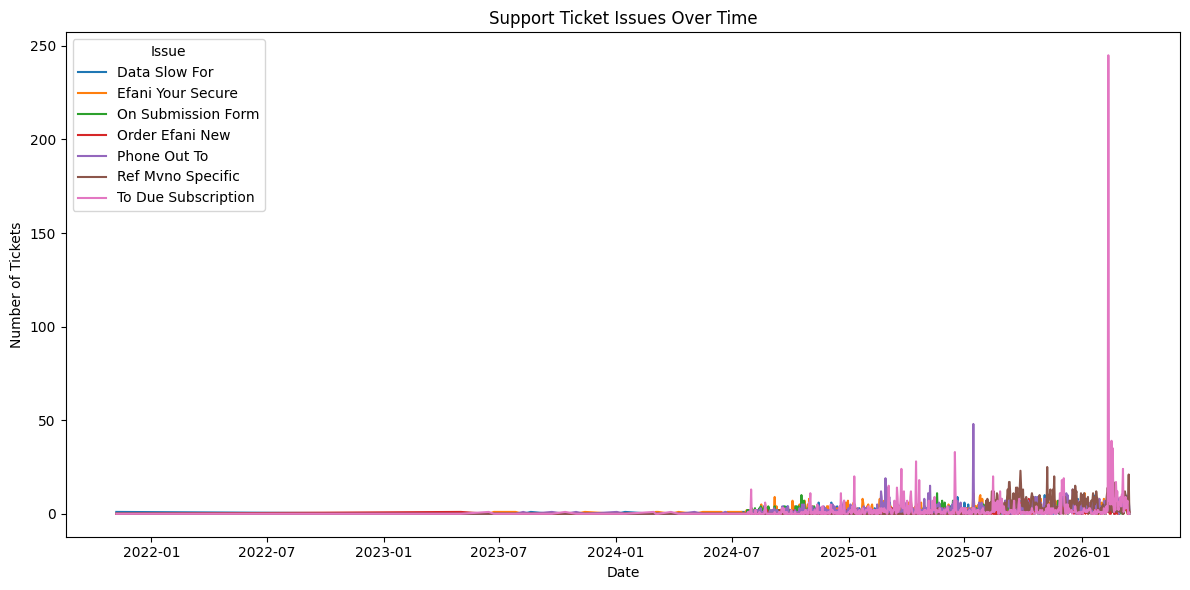

In [ ]:
# ==============================
# 1. Import Libraries
# ==============================

import pandas as pd
import re
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import Counter


# ==============================
# 2. Load Dataset
# ==============================

df = pd.read_csv("preprocessed_zoho_tickets.csv")

df['subject'] = df['subject'].astype(str)
df['createdTime'] = pd.to_datetime(df['createdTime'])


# ==============================
# 3. Clean Subject Lines
# ==============================

def clean_text(text):

    text = text.lower()

    # remove email prefixes
    text = re.sub(r"re:|fwd:|fw:", "", text)

    # remove special characters
    text = re.sub(r"[^a-z\s]", "", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df['clean_subject'] = df['subject'].apply(clean_text)


# ==============================
# 4. Load AI Semantic Model
# ==============================

print("Loading AI model...")

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')


# ==============================
# 5. Convert Subjects to Embeddings
# ==============================

print("Converting subjects to embeddings...")

embeddings = model.encode(df['clean_subject'], show_progress_bar=True)


# ==============================
# 6. Automatically Find Best Number of Clusters
# ==============================

print("Finding optimal number of clusters...")

best_k = 2
best_score = -1

for k in range(2,10):

    kmeans = KMeans(n_clusters=k, random_state=42)

    labels = kmeans.fit_predict(embeddings)

    score = silhouette_score(embeddings, labels)

    if score > best_score:

        best_k = k
        best_score = score


print("Best number of clusters:", best_k)


# ==============================
# 7. Final Clustering
# ==============================

kmeans = KMeans(n_clusters=best_k, random_state=42)

df['cluster'] = kmeans.fit_predict(embeddings)


# ==============================
# 8. Generate Issue Names
# ==============================

issue_labels = {}

for cluster_id in range(best_k):

    cluster_text = " ".join(df[df['cluster']==cluster_id]['clean_subject'])

    words = cluster_text.split()

    common_words = [w for w,_ in Counter(words).most_common(3)]

    label = " ".join(common_words).title()

    issue_labels[cluster_id] = label


df['issue_name'] = df['cluster'].map(issue_labels)


# ==============================
# 9. Issue Summary
# ==============================

summary = df.groupby('issue_name').agg(

    ticket_count=('subject','count'),

    first_ticket=('createdTime','min'),

    last_ticket=('createdTime','max')

).sort_values(by='ticket_count', ascending=False)


print("\n==============================")
print("ISSUE SUMMARY")
print("==============================\n")

print(summary)


# ==============================
# 10. Most Occurring Issue
# ==============================

top_issue = summary.index[0]

top_count = summary.iloc[0]['ticket_count']

print("\nMost Occurring Issue:", top_issue)

print("Number of Tickets:", top_count)


# ==============================
# 11. Issue Trends Over Time
# ==============================

df['date'] = df['createdTime'].dt.date

trend = df.groupby(['date','issue_name']).size().unstack(fill_value=0)

print("\n==============================")
print("ISSUE TREND TABLE")
print("==============================\n")

print(trend)


# ==============================
# 12. Plot Issue Trends
# ==============================

trend.plot(figsize=(12,6))

plt.title("Support Ticket Issues Over Time")

plt.xlabel("Date")

plt.ylabel("Number of Tickets")

plt.legend(title="Issue")

plt.tight_layout()

plt.show()


Loading dataset...
Total tickets loaded: 8697

Loading AI model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings...


Batches:   0%|          | 0/272 [00:00<?, ?it/s]


Finding optimal number of clusters...
Best number of clusters: 9

Clustering tickets...

ISSUE SUMMARY

                          ticket_count              first_ticket  \
issue_name                                                         
Phone To Service                  2648 2021-11-07 08:45:38+00:00   
Ref Mvno Specific                 1335 2024-08-08 00:10:27+00:00   
Efani Your Secure                 1105 2023-06-23 17:36:44+00:00   
On Efani Submission                860 2024-07-25 09:23:41+00:00   
Billing Reminder Payment           779 2023-10-13 16:47:38+00:00   
To Due Subscription                674 2024-02-29 19:30:01+00:00   
Order Efani New                    588 2023-05-02 15:53:54+00:00   
Data Esim Slow                     506 2024-07-01 20:38:10+00:00   
Out Port Request                   202 2024-10-13 03:57:59+00:00   

                                       last_ticket  percentage  
issue_name                                                      
Phone To Service

<Figure size 1200x600 with 0 Axes>

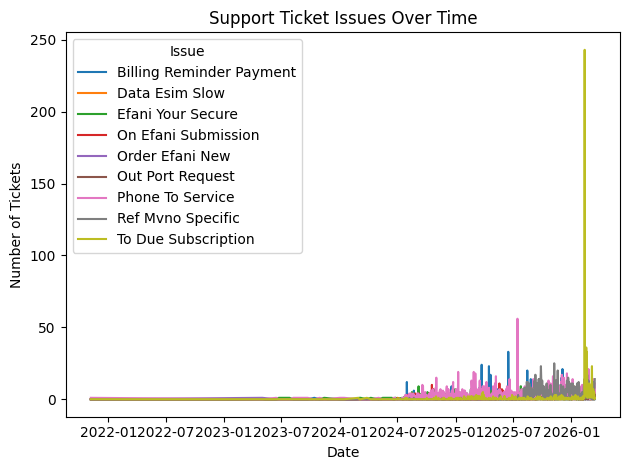

In [ ]:
# =====================================
# 1. Import Required Libraries
# =====================================

import pandas as pd
import re
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import Counter


# =====================================
# 2. Load Dataset
# =====================================

print("Loading dataset...")

df = pd.read_csv("preprocessed_zoho_tickets.csv")

# Ensure correct data types
df["subject"] = df["subject"].astype(str)
df["createdTime"] = pd.to_datetime(df["createdTime"])

print("Total tickets loaded:", len(df))


# =====================================
# 3. Clean Ticket Subject Text
# =====================================

def clean_text(text):

    text = text.lower()

    # Remove email prefixes
    text = re.sub(r"(re:|fw:|fwd:)", "", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_subject"] = df["subject"].apply(clean_text)


# =====================================
# 4. Load Semantic AI Model
# =====================================

print("\nLoading AI model...")

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")


# =====================================
# 5. Convert Subjects to Embeddings
# =====================================

print("Generating embeddings...")

embeddings = model.encode(
    df["clean_subject"],
    show_progress_bar=True
)


# =====================================
# 6. Determine Optimal Cluster Count
# =====================================

print("\nFinding optimal number of clusters...")

best_k = 2
best_score = -1

for k in range(2, 10):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(embeddings)

    score = silhouette_score(embeddings, labels)

    if score > best_score:
        best_k = k
        best_score = score

print("Best number of clusters:", best_k)


# =====================================
# 7. Perform Final Clustering
# =====================================

print("\nClustering tickets...")

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(embeddings)


# =====================================
# 8. Generate Issue Names
# =====================================

issue_labels = {}

for cluster_id in range(best_k):

    cluster_text = " ".join(
        df[df["cluster"] == cluster_id]["clean_subject"]
    )

    words = cluster_text.split()

    common_words = [
        w for w, _ in Counter(words).most_common(3)
    ]

    label = " ".join(common_words).title()

    issue_labels[cluster_id] = label

df["issue_name"] = df["cluster"].map(issue_labels)


# =====================================
# 9. Issue Summary
# =====================================

summary = (
    df.groupby("issue_name")
    .agg(
        ticket_count=("subject", "count"),
        first_ticket=("createdTime", "min"),
        last_ticket=("createdTime", "max")
    )
    .sort_values("ticket_count", ascending=False)
)

# Calculate percentages
summary["percentage"] = (
    summary["ticket_count"] /
    summary["ticket_count"].sum() * 100
).round(2)


print("\n==============================")
print("ISSUE SUMMARY")
print("==============================\n")

print(summary)


# =====================================
# 10. Total Tickets
# =====================================

total_tickets = summary["ticket_count"].sum()

print("\n==============================")
print("TOTAL TICKETS ANALYZED")
print("==============================")

print(total_tickets)


# =====================================
# 11. Most Frequent Issue
# =====================================

top_issue = summary.index[0]
top_count = summary.iloc[0]["ticket_count"]

print("\nMost Occurring Issue:", top_issue)
print("Number of Tickets:", top_count)


# =====================================
# 12. Issue Trends Over Time
# =====================================

df["date"] = df["createdTime"].dt.date

trend = (
    df.groupby(["date", "issue_name"])
    .size()
    .unstack(fill_value=0)
)

print("\n==============================")
print("ISSUE TREND TABLE")
print("==============================\n")

print(trend)


# =====================================
# 13. Plot Issue Trends
# =====================================

plt.figure(figsize=(12,6))

trend.plot()

plt.title("Support Ticket Issues Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Tickets")
plt.legend(title="Issue")

plt.tight_layout()
plt.show()


In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# ==============================
# 1️⃣ Filter tickets for last 30 days
# ==============================
last_30_days = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=30)
df_last_30 = df[df["createdTime"] >= last_30_days].copy()

if df_last_30.empty:
    print("No tickets in the last 30 days.")
else:
    print(f"Tickets in last 30 days: {len(df_last_30)}")

# ==============================
# 2️⃣ Calculate resolution time in hours (if modifiedTime exists)
# ==============================
if "modifiedTime" in df_last_30.columns:
    df_last_30["resolution_hours"] = (
        df_last_30["modifiedTime"] - df_last_30["createdTime"]
    ).dt.total_seconds() / 3600
else:
    df_last_30["resolution_hours"] = None

# ==============================
# 3️⃣ Create folder for outputs
# ==============================
output_folder = "all_issues_last_30_days"
os.makedirs(output_folder, exist_ok=True)

# ==============================
# 4️⃣ Generate files for each issue
# ==============================
for issue_name, group in df_last_30.groupby("issue_name"):

    # Clean issue name for filenames
    safe_issue_name = issue_name.replace(" ", "_").replace("/", "_")

    # Save CSV
    csv_path = os.path.join(output_folder, f"{safe_issue_name}.csv")
    group.to_csv(csv_path, index=False)

    # Plot ticket trend
    trend_issue = group.groupby(group["createdTime"].dt.date).size()

    plt.figure(figsize=(8,4))
    trend_issue.plot(marker="o")
    plt.title(f"Issue Trend: {issue_name} (Last 30 Days)")
    plt.xlabel("Date")
    plt.ylabel("Number of Tickets")
    plt.tight_layout()

    # Save plot
    plot_path = os.path.join(output_folder, f"{safe_issue_name}_trend.png")
    plt.savefig(plot_path)
    plt.close()

print(f"✅ All issue CSVs and trend plots saved in folder '{output_folder}'")

Tickets in last 30 days: 959


KeyError: 'issue_name'

In [ ]:
import os
import matplotlib.pyplot as plt

# ==============================
# 1️⃣ Filter tickets for last 30 days
# ==============================
last_30_days = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=30)
df_last_30 = df[df["createdTime"] >= last_30_days].copy()

print(f"\nTotal tickets in last 30 days: {len(df_last_30)}")

# ==============================
# 2️⃣ Calculate resolution time
# ==============================
if "modifiedTime" in df_last_30.columns:
    df_last_30["resolution_hours"] = (
        df_last_30["modifiedTime"] - df_last_30["createdTime"]
    ).dt.total_seconds() / 3600
else:
    df_last_30["resolution_hours"] = None

# ==============================
# 3️⃣ Create folder
# ==============================
output_folder = "all_issues_last_30_days"
os.makedirs(output_folder, exist_ok=True)

# ==============================
# 4️⃣ Process each issue
# ==============================
for issue_name, group in df_last_30.groupby("issue_name"):

    print("\n===================================")
    print(f"ISSUE: {issue_name}")
    print(f"Total Tickets: {len(group)}")
    print("Tickets involved:")

    # Print ticket subjects
    for s in group["subject"].head(10):
        print("- ", s)

    # Save CSV
    safe_issue_name = issue_name.replace(" ", "_").replace("/", "_")
    csv_path = os.path.join(output_folder, f"{safe_issue_name}.csv")
    group.to_csv(csv_path, index=False)

    # Plot trend
    trend_issue = group.groupby(group["createdTime"].dt.date).size()

    plt.figure(figsize=(8,4))
    trend_issue.plot(marker="o", label=issue_name)
    plt.title(f"Issue Trend: {issue_name} (Last 30 Days)")
    plt.xlabel("Date")
    plt.ylabel("Number of Tickets")
    plt.legend(title="Issue")

    plot_path = os.path.join(output_folder, f"{safe_issue_name}_trend.png")
    plt.savefig(plot_path)
    plt.close()

print("\n✅ All issues processed and files saved.")

print("\n================ ALL ISSUES (FULL DATASET) ================\n")

# Conditionally calculate resolution_hours for the full dataset if 'modifiedTime' exists
if "modifiedTime" in df.columns:
    df["resolution_hours"] = (
        df["modifiedTime"] - df["createdTime"]
    ).dt.total_seconds() / 3600
    issue_summary = (
        df.groupby("issue_name")
        .agg(
            total_tickets=("issue_name", "count"),
            avg_resolution_hours=("resolution_hours", "mean")
        )
        .sort_values(by="total_tickets", ascending=False)
    )
else:
    print("Note: 'modifiedTime' column not found in the full dataset, skipping average resolution time calculation.")
    issue_summary = (
        df.groupby("issue_name")
        .agg(
            total_tickets=("issue_name", "count")
        )
        .sort_values(by="total_tickets", ascending=False)
    )

for issue, row in issue_summary.iterrows():
    print(f"Issue: {issue}")
    print(f"Total Tickets: {row['total_tickets']}")

    # Only print average resolution time if the column exists in issue_summary
    if "avg_resolution_hours" in issue_summary.columns and pd.notna(row["avg_resolution_hours"]):
        print(f"Average Resolution Time: {round(row['avg_resolution_hours'],2)} hours")

    print("--------------------------------------------------")



Total tickets in last 30 days: 959


KeyError: 'issue_name'

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1️⃣ Convert timestamps to datetime
# ==============================

df["createdTime"] = pd.to_datetime(df["createdTime"], utc=True, errors="coerce")

if "modifiedTime" in df.columns:
    df["modifiedTime"] = pd.to_datetime(df["modifiedTime"], utc=True, errors="coerce")

# ==============================
# 2️⃣ Filter tickets for last 30 days
# ==============================

now = pd.Timestamp.now(tz="UTC")
last_30_days = now - pd.Timedelta(days=30)

df_last_30 = df[df["createdTime"] >= last_30_days].copy()

print("\n===============================")
print(f"Total tickets in last 30 days: {len(df_last_30)}")
print("===============================\n")

# ==============================
# 3️⃣ Calculate resolution time
# ==============================

if "modifiedTime" in df.columns:
    df["resolution_hours"] = (
        df["modifiedTime"] - df["createdTime"]
    ).dt.total_seconds() / 3600

    df_last_30["resolution_hours"] = (
        df_last_30["modifiedTime"] - df_last_30["createdTime"]
    ).dt.total_seconds() / 3600
else:
    df["resolution_hours"] = None
    df_last_30["resolution_hours"] = None

# ==============================
# 4️⃣ Create output folder
# ==============================

output_folder = "issue_analysis_last_30_days"
os.makedirs(output_folder, exist_ok=True)

# ==============================
# 5️⃣ Process issues (Last 30 Days)
# ==============================

for issue_name, group in df_last_30.groupby("issue_name"):

    print("\n===================================")
    print(f"ISSUE: {issue_name}")
    print(f"Total Tickets: {len(group)}")

    if "resolution_hours" in group.columns:
        avg_res = group["resolution_hours"].mean()
        if pd.notna(avg_res):
            print(f"Average Resolution Time: {round(avg_res,2)} hours")

    print("Tickets involved:")

    for s in group["subject"].head(10):
        print("-", s)

    # --------------------------
    # Save CSV
    # --------------------------

    safe_issue_name = issue_name.replace(" ", "_").replace("/", "_")

    csv_path = os.path.join(output_folder, f"{safe_issue_name}.csv")
    group.to_csv(csv_path, index=False)

    # --------------------------
    # Trend plot
    # --------------------------

    trend_issue = group.groupby(group["createdTime"].dt.date).size()

    plt.figure(figsize=(8,4))
    trend_issue.plot(marker="o")

    plt.title(f"Issue Trend: {issue_name} (Last 30 Days)")
    plt.xlabel("Date")
    plt.ylabel("Number of Tickets")
    plt.tight_layout()

    plot_path = os.path.join(output_folder, f"{safe_issue_name}_trend.png")

    plt.savefig(plot_path)
    plt.close()

print("\n✅ Last 30 day issue files saved.")

# ==============================
# 6️⃣ FULL DATASET ISSUE SUMMARY
# ==============================

print("\n================ ALL ISSUES (FULL DATASET) ================\n")

issue_summary = (
    df.groupby("issue_name")
    .agg(
        total_tickets=("issue_name", "count"),
        avg_resolution_hours=("resolution_hours", "mean")
    )
    .sort_values(by="total_tickets", ascending=False)
)

total_tickets_all = issue_summary["total_tickets"].sum()

for issue, row in issue_summary.iterrows():

    percent = (row["total_tickets"] / total_tickets_all) * 100

    print(f"Issue: {issue}")
    print(f"Total Tickets: {row['total_tickets']} ({percent:.2f}%)")

    if pd.notna(row["avg_resolution_hours"]):
        print(f"Average Resolution Time: {round(row['avg_resolution_hours'],2)} hours")

    print("--------------------------------------------------")

# ==============================
# 7️⃣ Save master summary
# ==============================

summary_file = "all_issues_full_summary.csv"
issue_summary.to_csv(summary_file)

print(f"\n📄 Full issue summary saved to: {summary_file}")



Total tickets in last 30 days: 959


ISSUE: Billing Payment Reminder
Total Tickets: 108
Tickets involved:
- Friendly Payment Reminder
- Friendly Payment Reminder
- Friendly Payment Reminder
- Friendly Payment Reminder
- Friendly Payment Reminder
- Friendly Payment Reminder
- Friendly Payment Reminder
- Payment Reminder – Action Required to Avoid Service Disruption
- Friendly Payment Reminder
- Re: [## 43689 ##] Billing PAID YEAR IN FULL

ISSUE: Data Slow Issue
Total Tickets: 42
Tickets involved:
- Slow data
- Poor internet when using cellular data
- Slow data
- Slow Data Connection
- Slow data
- Slow data
- Slow data
- Slow data
- Slow data
- Internet access is VERY slow

ISSUE: Efani Support Secure
Total Tickets: 108
Tickets involved:
- Efani Invoice
- Re: Your receipt from EFANI Secure Mobile #2522-7193
- [SOLVED] [HD Support] Re: Live chat with support@efani.com
- Re: EFANI - Reset Your Password
- Efani - New Line Added By Customer
- Re: $74.00 payment to EFANI Secure Mobile was un

In [ ]:
# =====================================
# 0️⃣ Imports and Setup
# =====================================
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from collections import Counter

# Ensure plots inline if using Jupyter
%matplotlib inline

# =====================================
# 1️⃣ Load Dataset
# =====================================
df = pd.read_csv("preprocessed_zoho_tickets.csv")

# Ensure correct data types
df["subject"] = df["subject"].astype(str)
df["createdTime"] = pd.to_datetime(df["createdTime"])
if "modifiedTime" in df.columns:
    df["modifiedTime"] = pd.to_datetime(df["modifiedTime"])

# Fill empty description if not present
if "description" not in df.columns:
    df["description"] = ""

df["ticket_text"] = df["subject"] + " " + df["description"]

# =====================================
# 2️⃣ Calculate resolution time (hours)
# =====================================
if "modifiedTime" in df.columns:
    df["resolution_hours"] = (df["modifiedTime"] - df["createdTime"]).dt.total_seconds() / 3600
else:
    df["resolution_hours"] = None

# =====================================
# 3️⃣ Generate semantic embeddings (AI)
# =====================================
print("Loading AI model and generating embeddings...")
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df["ticket_text"].tolist(), show_progress_bar=True)

# =====================================
# 4️⃣ Cluster tickets into issues
# =====================================
# You can adjust number of clusters or use silhouette score to find optimal
n_clusters = min(10, len(df)//50)  # rough heuristic
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df["issue_cluster"] = kmeans.fit_predict(embeddings)

# =====================================
# 5️⃣ Generate human-readable issue names
# =====================================
def generate_issue_name(texts):
    words = []
    for t in texts:
        clean = re.sub(r"[^a-zA-Z ]", "", t.lower())
        words.extend(clean.split())
    stop_words = {
        "the","and","to","for","your","from",
        "with","this","that","have","help","please","re","fw","fwd"
    }
    words = [w for w in words if w not in stop_words and len(w) > 3]
    common = Counter(words).most_common(3)
    return " ".join([w[0].capitalize() for w in common]) if common else "Miscellaneous"

issue_labels = {}
for cluster_id, group in df.groupby("issue_cluster"):
    issue_labels[cluster_id] = generate_issue_name(group["ticket_text"])

df["issue_name"] = df["issue_cluster"].map(issue_labels)

# =====================================
# 6️⃣ Save individual issue files & plots
# =====================================
output_folder = "all_issues_full_dataset"
os.makedirs(output_folder, exist_ok=True)

for issue_name, group in df.groupby("issue_name"):
    safe_issue_name = issue_name.replace(" ", "_").replace("/", "_")

    # Save CSV
    group.to_csv(os.path.join(output_folder, f"{safe_issue_name}.csv"), index=False)

    # Plot trend over time
    trend = group.groupby(group["createdTime"].dt.date).size()
    plt.figure(figsize=(8,4))
    trend.plot(marker="o", title=f"Issue Trend: {issue_name}")
    plt.xlabel("Date")
    plt.ylabel("Number of Tickets")
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, f"{safe_issue_name}_trend.png"))
    plt.close()

print("✅ Individual issue files and trend plots saved.")

# =====================================
# 7️⃣ Full Issue Summary
# =====================================
if "resolution_hours" in df.columns and df["resolution_hours"].notna().any():
    issue_summary = df.groupby("issue_name").agg(
        total_tickets=("issue_name","count"),
        avg_resolution_hours=("resolution_hours","mean")
    ).sort_values("total_tickets", ascending=False)
else:
    issue_summary = df.groupby("issue_name").agg(
        total_tickets=("issue_name","count")
    ).sort_values("total_tickets", ascending=False)

# Save summary CSV
summary_csv = os.path.join(output_folder, "all_issues_full_summary.csv")
issue_summary.to_csv(summary_csv)

# Print full summary
print("\n================ ALL ISSUES SUMMARY ================\n")
for issue, row in issue_summary.iterrows():
    print(f"Issue: {issue}")
    print(f"Total Tickets: {row['total_tickets']}")
    if "avg_resolution_hours" in row:
        print(f"Average Resolution Time: {round(row['avg_resolution_hours'],2)} hours")
    print("--------------------------------------------------")

print(f"\n📄 Full issue summary saved to: {summary_csv}")

# =====================================
# 8️⃣ Optional: Last 30 days report
# =====================================
last_30_days = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=30)
df_last_30 = df[df["createdTime"] >= last_30_days].copy()

print(f"\n================ LAST 30 DAYS ================\nTotal tickets: {len(df_last_30)}")

for issue_name, group in df_last_30.groupby("issue_name"):
    print("\n===================================")
    print(f"ISSUE: {issue_name}")
    print(f"Total Tickets: {len(group)}")
    print("Tickets involved (examples):")
    for s in group["subject"].head(10):
        print("-", s)


Loading AI model and generating embeddings...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/273 [00:00<?, ?it/s]

✅ Individual issue files and trend plots saved.

================ ALL ISSUES SUMMARY ================

Issue: Phone Service Request
Total Tickets: 2555
--------------------------------------------------
Issue: Efani Support Secure
Total Tickets: 1349
--------------------------------------------------
Issue: Mvno Specific Inquiry
Total Tickets: 1045
--------------------------------------------------
Issue: Billing Payment Reminder
Total Tickets: 912
--------------------------------------------------
Issue: Submission Form Efani
Total Tickets: 856
--------------------------------------------------
Issue: Subscription Canceled Failed
Total Tickets: 608
--------------------------------------------------
Issue: Order Efani Line
Total Tickets: 588
--------------------------------------------------
Issue: Mvno Helixefani Specific
Total Tickets: 297
--------------------------------------------------
Issue: Esim Data Global
Total Tickets: 271
--------------------------------------------------
I

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# ===============================
# Configurable settings
# ===============================
last_n_days = 30           # Number of days to filter for recent tickets
top_n_examples = 10        # Number of ticket subjects to display per issue
output_base = "outputs"    # Base folder for outputs
timestamp_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# ===============================
# Prepare output folders
# ===============================
output_folder = os.path.join(output_base, timestamp_str, f"issues_last_{last_n_days}_days")
os.makedirs(output_folder, exist_ok=True)
full_dataset_folder = os.path.join(output_base, timestamp_str, "all_issues_full_dataset")
os.makedirs(full_dataset_folder, exist_ok=True)

# ===============================
# Filter last N days tickets
# ===============================
last_days_ts = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=last_n_days)
df_last_n_days = df[df["createdTime"] >= last_days_ts].copy()

print(f"\n===============================")
print(f"Total tickets in last {last_n_days} days: {len(df_last_n_days)}")
print(f"===============================\n")

# ===============================
# Calculate resolution times
# ===============================
if "modifiedTime" in df.columns:
    df_last_n_days["resolution_hours"] = (df_last_n_days["modifiedTime"] - df_last_n_days["createdTime"]).dt.total_seconds() / 3600
    df["resolution_hours"] = (df["modifiedTime"] - df["createdTime"]).dt.total_seconds() / 3600
else:
    df_last_n_days["resolution_hours"] = None
    df["resolution_hours"] = None

# ===============================
# Process each issue in last N days
# ===============================
for issue_name, group in df_last_n_days.groupby("issue_name"):
    print("\n===================================")
    print(f"ISSUE: {issue_name}")
    print(f"Total Tickets: {len(group)}")
    print(f"Percentage of last {last_n_days} days: {len(group)/len(df_last_n_days)*100:.2f}%")
    print("Tickets involved (examples):")

    # Print top N examples
    for s in group["subject"].fillna("(No Subject)").head(top_n_examples):
        print("- ", s)

    # Save CSV for this issue
    safe_issue_name = issue_name.replace(" ", "_").replace("/", "_")
    csv_path = os.path.join(output_folder, f"{safe_issue_name}.csv")
    group.to_csv(csv_path, index=False)

    # Plot trend
    trend_issue = group.groupby(group["createdTime"].dt.date).size()
    plt.figure(figsize=(8,4))
    trend_issue.plot(marker="o", label=issue_name)
    plt.title(f"Issue Trend: {issue_name} (Last {last_n_days} Days)")
    plt.xlabel("Date")
    plt.ylabel("Number of Tickets")
    plt.legend(title="Issue")
    plot_path = os.path.join(output_folder, f"{safe_issue_name}_trend.png")
    plt.savefig(plot_path)
    plt.close()

print(f"\n✅ Last {last_n_days} day issue files saved: {output_folder}\n")

# ===============================
# Full dataset summary
# ===============================
issue_summary = df.groupby("issue_name").agg(
    total_tickets=("issue_name", "count"),
    avg_resolution_hours=("resolution_hours", "mean"),
    min_resolution_hours=("resolution_hours", "min"),
    max_resolution_hours=("resolution_hours", "max")
).sort_values(by="total_tickets", ascending=False)

# Print full summary
print("\n================ ALL ISSUES (FULL DATASET) ================\n")
for issue, row in issue_summary.iterrows():
    print(f"Issue: {issue}")
    print(f"Total Tickets: {row['total_tickets']} ({row['total_tickets']/len(df)*100:.2f}%)")
    if pd.notna(row["avg_resolution_hours"]):
        print(f"Average Resolution Time: {row['avg_resolution_hours']:.2f} hrs")
        print(f"Min Resolution Time: {row['min_resolution_hours']:.2f} hrs")
        print(f"Max Resolution Time: {row['max_resolution_hours']:.2f} hrs")
    print("--------------------------------------------------")

# ===============================
# Save full summary to CSV & Excel
# ===============================
csv_summary_path = os.path.join(full_dataset_folder, f"all_issues_full_summary_{timestamp_str}.csv")
issue_summary.to_csv(csv_summary_path, index=True)

excel_summary_path = os.path.join(full_dataset_folder, f"all_issues_full_summary_{timestamp_str}.xlsx")

# Temporarily convert datetime columns to be timezone-naive for Excel export
df_excel = df.copy()
if "createdTime" in df_excel.columns and df_excel["createdTime"].dt.tz is not None:
    df_excel["createdTime"] = df_excel["createdTime"].dt.tz_localize(None)
if "modifiedTime" in df_excel.columns and df_excel["modifiedTime"].dt.tz is not None:
    df_excel["modifiedTime"] = df_excel["modifiedTime"].dt.tz_localize(None)

with pd.ExcelWriter(excel_summary_path) as writer:
    df_excel.to_excel(writer, sheet_name="Full Tickets", index=False)
    issue_summary.to_excel(writer, sheet_name="Issue Summary", index=True)

print(f"\n📄 Full issue summary saved to: {csv_summary_path}")
print(f"📄 Full Excel report saved to: {excel_summary_path}")



Total tickets in last 30 days: 959


ISSUE: Billing Payment Reminder
Total Tickets: 108
Percentage of last 30 days: 11.26%
Tickets involved (examples):
-  Friendly Payment Reminder
-  Friendly Payment Reminder
-  Friendly Payment Reminder
-  Friendly Payment Reminder
-  Friendly Payment Reminder
-  Friendly Payment Reminder
-  Friendly Payment Reminder
-  Payment Reminder – Action Required to Avoid Service Disruption
-  Friendly Payment Reminder
-  Re: [## 43689 ##] Billing PAID YEAR IN FULL

ISSUE: Data Slow Issue
Total Tickets: 42
Percentage of last 30 days: 4.38%
Tickets involved (examples):
-  Slow data
-  Poor internet when using cellular data
-  Slow data
-  Slow Data Connection
-  Slow data
-  Slow data
-  Slow data
-  Slow data
-  Slow data
-  Internet access is VERY slow

ISSUE: Efani Support Secure
Total Tickets: 108
Percentage of last 30 days: 11.26%
Tickets involved (examples):
-  Efani Invoice
-  Re: Your receipt from EFANI Secure Mobile #2522-7193
-  [SOLVED] [HD Support

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import pytz

# ==============================
# 1❤‸  Load dataset (Removed: df is already available with 'issue_name' from previous cells)
# ==============================
# df = pd.read_csv("preprocessed_zoho_tickets.csv") # This line is removed

# ==============================
# 2❤‸  Standardize timestamps
# ==============================
df["createdTime"] = pd.to_datetime(df["createdTime"][df["createdTime"].notna()], errors="coerce", utc=True)
if "modifiedTime" in df.columns:
    df["modifiedTime"] = pd.to_datetime(df["modifiedTime"][df["modifiedTime"].notna()], errors="coerce", utc=True)

# Optional: convert to local timezone (change as needed)
local_tz = pytz.timezone("Asia/Karachi")

df["createdTime_local"] = df["createdTime"].dt.tz_convert(local_tz)
if "modifiedTime" in df.columns:
    df["modifiedTime_local"] = df["modifiedTime"].dt.tz_convert(local_tz)

# ==============================
# 3❤‸  Clean text columns
# ==============================
import re
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"(re:|fw:|fwd:)", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_subject"] = df["subject"].apply(clean_text)

# ==============================
# 4❤‸  Calculate resolution hours
# ==============================
if "modifiedTime_local" in df.columns:
    df["resolution_hours"] = (df["modifiedTime_local"] - df["createdTime_local"]).dt.total_seconds() / 3600
else:
    df["resolution_hours"] = None

# ==============================
# 5❤‸  Create output folders
# ==============================
output_folder = "all_issues_reports"
os.makedirs(output_folder, exist_ok=True)
trend_folder = os.path.join(output_folder, "trends")
os.makedirs(trend_folder, exist_ok=True)

# ==============================
# 6❤‸  Process all issues
# ==============================
issue_summary = []

for issue_name, group in df.groupby("issue_name"):
    total_tickets = len(group)
    avg_resolution = group["resolution_hours"].mean() if "resolution_hours" in group.columns else None

    # Save individual CSV for each issue
    safe_name = issue_name.replace(" ", "_").replace("/", "_")
    csv_path = os.path.join(output_folder, f"{safe_name}.csv")
    group.to_csv(csv_path, index=False)

    # Plot issue trend over time
    trend = group.groupby(group["createdTime_local"].dt.date).size()
    plt.figure(figsize=(8,4))
    trend.plot(marker="o", title=f"Issue Trend: {issue_name}")
    plt.xlabel("Date")
    plt.ylabel("Number of Tickets")
    plt.tight_layout()
    plt.savefig(os.path.join(trend_folder, f"{safe_name}_trend.png"))
    plt.close()

    # Append to summary
    issue_summary.append({
        "issue_name": issue_name,
        "total_tickets": total_tickets,
        "avg_resolution_hours": round(avg_resolution,2) if avg_resolution is not None else None
    })

# ==============================
# 7❤‸  Create summary DataFrame
# ==============================
summary_df = pd.DataFrame(issue_summary).sort_values(by="total_tickets", ascending=False)
summary_df["percentage"] = (summary_df["total_tickets"] / summary_df["total_tickets"].sum() * 100).round(2)

# Save full summary CSV and Excel
csv_summary_path = os.path.join(output_folder, "all_issues_full_summary.csv")
excel_summary_path = os.path.join(output_folder, "all_issues_full_summary.xlsx")

summary_df.to_csv(csv_summary_path, index=False)

# Create a copy of the dataframe and make datetime columns timezone-naive for Excel export
df_for_excel = df.copy()
for col in ["createdTime", "modifiedTime", "createdTime_local", "modifiedTime_local"]:
    if col in df_for_excel.columns and df_for_excel[col].dt.tz is not None:
        df_for_excel[col] = df_for_excel[col].dt.tz_localize(None)

with pd.ExcelWriter(excel_summary_path) as writer:
    df_for_excel.to_excel(writer, sheet_name="Full Tickets", index=False)
    summary_df.to_excel(writer, sheet_name="Issue Summary", index=True)

print(f"✅ All issues processed and reports saved in '{output_folder}'")
print(f"☑  Full summary CSV: {csv_summary_path}")
print(f"☑  Full summary Excel: {excel_summary_path}")

✅ All issues processed and reports saved in 'all_issues_reports'
☑  Full summary CSV: all_issues_reports/all_issues_full_summary.csv
☑  Full summary Excel: all_issues_reports/all_issues_full_summary.xlsx


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1️⃣ Load dataset
# ==============================
df = pd.read_csv("preprocessed_zoho_tickets.csv")

# Ensure proper datetime format
df["createdTime"] = pd.to_datetime(df["createdTime"], utc=True, errors="coerce")
if "modifiedTime" in df.columns:
    df["modifiedTime"] = pd.to_datetime(df["modifiedTime"], utc=True, errors="coerce")

# ==============================
# 2️⃣ Convert timestamps to local time (optional)
# ==============================
df["createdTime_local"] = df["createdTime"].dt.tz_convert('Asia/Karachi')
if "modifiedTime" in df.columns:
    df["modifiedTime_local"] = df["modifiedTime"].dt.tz_convert('Asia/Karachi')

# ==============================
# 3️⃣ Calculate resolution time in hours
# ==============================
if "modifiedTime_local" in df.columns:
    df["resolution_hours"] = (
        df["modifiedTime_local"] - df["createdTime_local"]
    ).dt.total_seconds() / 3600
else:
    df["resolution_hours"] = None

# ==============================
# 4️⃣ Create issue_name column (take first 5 words as simple issue label)
# ==============================
df["issue_name"] = df["subject"].astype(str).str.lower().str.strip().str.replace(r"[^a-z0-9\s]", "", regex=True)
df["issue_name"] = df["issue_name"].apply(lambda x: " ".join(x.split()[:5]))

# ==============================
# 5️⃣ Create folders for outputs
# ==============================
output_folder = "all_issues_last_30_days"
trend_folder = os.path.join(output_folder, "plots")
os.makedirs(output_folder, exist_ok=True)
os.makedirs(trend_folder, exist_ok=True)

# ==============================
# 6️⃣ Filter last 30 days
# ==============================
last_30_days = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=30)
df_last_30 = df[df["createdTime"] >= last_30_days].copy()

print(f"Total tickets in last 30 days: {len(df_last_30)}")

# ==============================
# 7️⃣ Process each issue
# ==============================
issue_summary = []

for issue_name, group in df.groupby("issue_name"):
    total_tickets = len(group)
    avg_resolution = group["resolution_hours"].mean() if "resolution_hours" in group.columns else None

    # Save CSV for each issue
    safe_name = issue_name.replace(" ", "_")[:50]  # limit filename length
    csv_path = os.path.join(output_folder, f"{safe_name}.csv")
    group.to_csv(csv_path, index=False)

    # Plot trend over time
    trend = group.groupby(group["createdTime_local"].dt.date).size()
    plt.figure(figsize=(8,4))
    trend.plot(marker="o", title=f"Issue Trend: {issue_name}")
    plt.xlabel("Date")
    plt.ylabel("Number of Tickets")
    plt.tight_layout()
    plt.savefig(os.path.join(trend_folder, f"{safe_name}_trend.png"))
    plt.close()

    # Append to summary
    issue_summary.append({
        "issue_name": issue_name,
        "total_tickets": total_tickets,
        "avg_resolution_hours": round(avg_resolution, 2) if avg_resolution is not None else None
    })

# ==============================
# 8️⃣ Save full summary CSV and Excel
# ==============================
df_summary = pd.DataFrame(issue_summary).sort_values("total_tickets", ascending=False)
csv_summary_path = os.path.join(output_folder, "all_issues_full_summary.csv")
excel_summary_path = os.path.join(output_folder, "all_issues_full_summary.xlsx")

df_summary.to_csv(csv_summary_path, index=False)

# Create a copy of df and convert datetime columns to be timezone-naive for Excel export
df_for_excel_export = df.copy()
for col in ["createdTime", "modifiedTime", "createdTime_local", "modifiedTime_local"]:
    if col in df_for_excel_export.columns and df_for_excel_export[col].dt.tz is not None:
        df_for_excel_export[col] = df_for_excel_export[col].dt.tz_localize(None)

with pd.ExcelWriter(excel_summary_path) as writer:
    df_for_excel_export.to_excel(writer, sheet_name="Full Tickets", index=False)
    df_summary.to_excel(writer, sheet_name="Issue Summary", index=False)

print(f"\n✅ All tickets processed.")
print(f"📄 Full CSV summary: {csv_summary_path}")
print(f"📄 Full Excel report: {excel_summary_path}")

Total tickets in last 30 days: 959

✅ All tickets processed.
📄 Full CSV summary: all_issues_last_30_days/all_issues_full_summary.csv
📄 Full Excel report: all_issues_last_30_days/all_issues_full_summary.xlsx


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import pytz

# ==============================
# 1❤‸  Load dataset (Removed: df is already available with 'issue_name' from previous cells)
# ==============================
# df = pd.read_csv("preprocessed_zoho_tickets.csv") # This line is removed

# ==============================
# 2❤‸  Standardize timestamps
# ==============================
df["createdTime"] = pd.to_datetime(df["createdTime"][df["createdTime"].notna()], errors="coerce", utc=True)
if "modifiedTime" in df.columns:
    df["modifiedTime"] = pd.to_datetime(df["modifiedTime"][df["modifiedTime"].notna()], errors="coerce", utc=True)

# Optional: convert to local timezone (change as needed)
local_tz = pytz.timezone("Asia/Karachi")

df["createdTime_local"] = df["createdTime"].dt.tz_convert(local_tz)
if "modifiedTime" in df.columns:
    df["modifiedTime_local"] = df["modifiedTime"].dt.tz_convert(local_tz)

# ==============================
# 3❤‸  Clean text columns
# ==============================
import re
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"(re:|fw:|fwd:)", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_subject"] = df["subject"].apply(clean_text)

# ==============================
# 4❤‸  Calculate resolution hours
# ==============================
if "modifiedTime_local" in df.columns:
    df["resolution_hours"] = (df["modifiedTime_local"] - df["createdTime_local"]).dt.total_seconds() / 3600
else:
    df["resolution_hours"] = None

# ==============================
# 5❤‸  Create output folders
# ==============================
output_folder = "all_issues_reports"
os.makedirs(output_folder, exist_ok=True)
trend_folder = os.path.join(output_folder, "trends")
os.makedirs(trend_folder, exist_ok=True)

# ==============================
# 6❤‸  Process all issues
# ==============================
issue_summary = []

for issue_name, group in df.groupby("issue_name"):
    total_tickets = len(group)
    avg_resolution = group["resolution_hours"].mean() if "resolution_hours" in group.columns else None

    # Save individual CSV for each issue
    safe_name = issue_name.replace(" ", "_").replace("/", "_")
    csv_path = os.path.join(output_folder, f"{safe_name}.csv")
    group.to_csv(csv_path, index=False)

    # Plot issue trend over time
    trend = group.groupby(group["createdTime_local"].dt.date).size()
    plt.figure(figsize=(8,4))
    trend.plot(marker="o", title=f"Issue Trend: {issue_name}")
    plt.xlabel("Date")
    plt.ylabel("Number of Tickets")
    plt.tight_layout()
    plt.savefig(os.path.join(trend_folder, f"{safe_name}_trend.png"))
    plt.close()

    # Append to summary
    issue_summary.append({
        "issue_name": issue_name,
        "total_tickets": total_tickets,
        "avg_resolution_hours": round(avg_resolution,2) if avg_resolution is not None else None
    })

# ==============================
# 7❤‸  Create summary DataFrame
# ==============================
summary_df = pd.DataFrame(issue_summary).sort_values(by="total_tickets", ascending=False)
summary_df["percentage"] = (summary_df["total_tickets"] / summary_df["total_tickets"].sum() * 100).round(2)

# Save full summary CSV and Excel
csv_summary_path = os.path.join(output_folder, "all_issues_full_summary.csv")
excel_summary_path = os.path.join(output_folder, "all_issues_full_summary.xlsx")

summary_df.to_csv(csv_summary_path, index=False)

# Create a copy of the dataframe and make datetime columns timezone-naive for Excel export
df_for_excel = df.copy()
for col in ["createdTime", "modifiedTime", "createdTime_local", "modifiedTime_local"]:
    if col in df_for_excel.columns and df_for_excel[col].dt.tz is not None:
        df_for_excel[col] = df_for_excel[col].dt.tz_localize(None)

with pd.ExcelWriter(excel_summary_path) as writer:
    df_for_excel.to_excel(writer, sheet_name="Full Tickets", index=False)
    summary_df.to_excel(writer, sheet_name="Issue Summary", index=True)

print(f"✅ All issues processed and reports saved in '{output_folder}'")
print(f"☑  Full summary CSV: {csv_summary_path}")
print(f"☑  Full summary Excel: {excel_summary_path}")

✅ All issues processed and reports saved in 'all_issues_reports'
☑  Full summary CSV: all_issues_reports/all_issues_full_summary.csv
☑  Full summary Excel: all_issues_reports/all_issues_full_summary.xlsx
